In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [29]:
# Загрузка данных
data = pd.read_csv('diabetes.txt', sep='\t', encoding='windows-1251')

print(f"\nРазмерность данных: {data.shape}")
print(f"\nИнформация о данных:")
print(data.info())

X = data.drop('Диагноз', axis=1) # признаки (удаляем диагнозы)
y = data['Диагноз'] # переменная для предсказаний



Размерность данных: (768, 9)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Беременность      768 non-null    int64  
 1   Глюкоза           768 non-null    int64  
 2   АД                768 non-null    int64  
 3   Толщина КС        768 non-null    float64
 4   Инсулин           768 non-null    float64
 5   ИМТ               768 non-null    float64
 6   Наследственность  768 non-null    float64
 7   Возраст           768 non-null    int64  
 8   Диагноз           768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None


In [25]:
# Делим данные на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Масштабируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Добавляем столбец единиц для коэффициента b (свободного члена)
X_train_scaled = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_scaled = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

# Реализация регрессии
class SimpleLogisticRegression:
    def __init__(self, learning_rate=0.1, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.weights = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)

        for i in range(self.n_iter):
            # Вычисляем предсказания
            linear_model = np.dot(X, self.weights)
            y_pred = self.sigmoid(linear_model)

            # Вычисляем градиент и обновляем веса
            gradient = np.dot(X.T, (y_pred - y)) / n_samples
            self.weights -= self.learning_rate * gradient

            if i % 200 == 0:
                loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
                print(f"Итерация {i}, Потери: {round(loss, 4)}")

    def predict(self, X):
        linear_model = np.dot(X, self.weights)
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= 0.5).astype(int)

# Обучаем модель
model_all = SimpleLogisticRegression(learning_rate=0.1, n_iter=1000)
model_all.fit(X_train_scaled, y_train)

# Делаем предсказания
y_pred_all = model_all.predict(X_test_scaled)
accuracy_all = accuracy_score(y_test, y_pred_all)

print(f"\nТочность модели (все признаки): {round(accuracy_all, 4)}")
print(f"Коэффициенты модели: {model_all.weights}")


Итерация 0, Потери: 0.6931
Итерация 200, Потери: 0.4769
Итерация 400, Потери: 0.4753
Итерация 600, Потери: 0.4752
Итерация 800, Потери: 0.4752

Точность модели (все признаки): 0.7597
Коэффициенты модели: [-0.80019255  0.22400161  1.02024009 -0.18828904 -0.07168187 -0.05195218
  0.8414794   0.12802005  0.40136549]


In [26]:
# Выбираем лучшие признаки по корреляции с целевой переменной
correlations = abs(X.corrwith(y))
print("Корреляции признаков с диагнозом:")
for i, (feature, corr) in enumerate(correlations.items()):
    print(f"  {feature}: {round(corr)}")

# Исключаем 2 признака с наименьшей корреляцией
n_features_to_keep = X.shape[1] - 2
selected_features = correlations.nlargest(n_features_to_keep).index.tolist()

print(f"\nОставляем {n_features_to_keep} лучших признаков: {selected_features}")

# Создаем новую матрицу признаков
X_selected = X[selected_features]

# Делим на обучение и тест
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.4, random_state=42)

# Масштабируем
scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

# Добавляем столбец единиц
X_train_sel_scaled = np.c_[np.ones(X_train_sel_scaled.shape[0]), X_train_sel_scaled]
X_test_sel_scaled = np.c_[np.ones(X_test_sel_scaled.shape[0]), X_test_sel_scaled]

# Обучаем новую модель
model_sel = SimpleLogisticRegression(learning_rate=0.1, n_iter=1000)
model_sel.fit(X_train_sel_scaled, y_train_sel)

# Предсказания
y_pred_sel = model_sel.predict(X_test_sel_scaled)
accuracy_sel = accuracy_score(y_test_sel, y_pred_sel)

print(f"\nТочность модели (отобранные признаки): {round(accuracy_sel,4)}")
print(f"Коэффициенты модели: {model_sel.weights}")


Корреляции признаков с диагнозом:
  Беременность: 0
  Глюкоза: 0
  АД: 0
  Толщина КС: 0
  Инсулин: 0
  ИМТ: 0
  Наследственность: 0
  Возраст: 0

Оставляем 6 лучших признаков: ['Глюкоза', 'ИМТ', 'Возраст', 'Беременность', 'Наследственность', 'Инсулин']
Итерация 0, Потери: 0.6931
Итерация 200, Потери: 0.4791
Итерация 400, Потери: 0.4779
Итерация 600, Потери: 0.4778
Итерация 800, Потери: 0.4778

Точность модели (отобранные признаки): 0.763
Коэффициенты модели: [-0.79906849  1.02529048  0.77238771  0.35664769  0.2183016   0.12117489
 -0.08340242]


Точность со всеми признаками: 0.7597
Точность с отобранными признаками: 0.763
Точность модели улучшена!


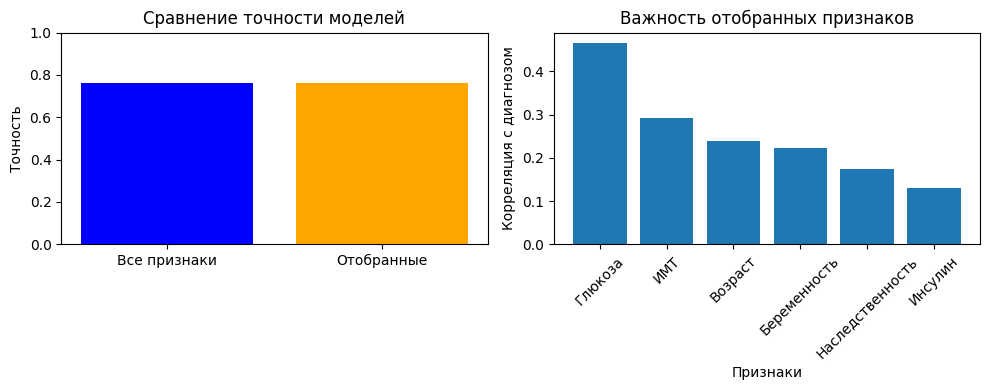

In [27]:
print(f"Точность со всеми признаками: {round(accuracy_all, 4)}")
print(f"Точность с отобранными признаками: {round(accuracy_sel, 4)}")

if accuracy_sel > accuracy_all:
    print("Точность модели улучшена!")
elif accuracy_sel < accuracy_all:
    print("Отбор признаков ухудшил точность модели...")
else:
    print("Точность не изменилась.")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(['Все признаки', 'Отобранные'], [accuracy_all, accuracy_sel], color=['blue', 'orange'])
plt.title('Сравнение точности моделей')
plt.ylabel('Точность')
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.bar(range(len(selected_features)), correlations[selected_features].values)
plt.title('Важность отобранных признаков')
plt.xlabel('Признаки')
plt.ylabel('Корреляция с диагнозом')
plt.xticks(range(len(selected_features)), selected_features, rotation=45)

plt.tight_layout()
plt.show()